## Understanding the structure of raw predictions

### Load full raw frames (10 frames in this case)

In [18]:
import numpy as np

raw_prediction_path = "co_detr-predictions-waymo/preds--training_0000-S1__co_dino_5scale_vit_large_coco_instance.npy"

preds = np.load(raw_prediction_path, allow_pickle=True)

In [ ]:
def explore_structure(obj, max_depth=3, current_depth=0, max_items=3):
    """Recursively explore the structure of an object and return a string representation."""
    indent = "  " * current_depth
    result = ""

    if current_depth >= max_depth:
        return indent + "... (max depth reached)\n"

    if isinstance(obj, np.ndarray):
        result += f"{indent}np.ndarray: shape={obj.shape}, dtype={obj.dtype}\n"
        if obj.dtype == np.dtype('O') and obj.size > 0:
            sample = obj.flatten()[:min(max_items, obj.size)]
            for i, item in enumerate(sample):
                if i < len(sample) - 1:
                    result += f"{indent}├─ Item {i}:\n"
                    child_indent = indent + "│  "
                else:
                    result += f"{indent}└─ Item {i}:\n"
                    child_indent = indent + "   "
                result += explore_structure(item, max_depth, current_depth + 1,
                                            max_items).replace(
                                                "  " * (current_depth + 1),
                                                child_indent, 1)
            if obj.size > max_items:
                result += f"{indent}└─ ... ({obj.size - max_items} more items)\n"

    elif isinstance(obj, dict):
        result += f"{indent}dict: {len(obj)} keys\n"
        items = list(obj.items())[:min(max_items, len(obj))]
        for i, (k, v) in enumerate(items):
            if i < len(items) - 1:
                result += f"{indent}├─ Key '{k}':\n"
                child_indent = indent + "│  "
            else:
                result += f"{indent}└─ Key '{k}':\n"
                child_indent = indent + "   "
            result += explore_structure(v, max_depth, current_depth + 1,
                                        max_items).replace(
                                            "  " * (current_depth + 1),
                                            child_indent, 1)
        if len(obj) > max_items:
            result += f"{indent}└─ ... ({len(obj) - max_items} more keys)\n"

    elif isinstance(obj, (list, tuple)):
        container_type = "list" if isinstance(obj, list) else "tuple"
        result += f"{indent}{container_type}: length={len(obj)}\n"
        items = obj[:min(max_items, len(obj))]
        for i, item in enumerate(items):
            if i < len(items) - 1:
                result += f"{indent}├─ Index {i}:\n"
                child_indent = indent + "│  "
            else:
                result += f"{indent}└─ Index {i}:\n"
                child_indent = indent + "   "
            result += explore_structure(item, max_depth, current_depth + 1,
                                        max_items).replace(
                                            "  " * (current_depth + 1),
                                            child_indent, 1)
        if len(obj) > max_items:
            result += f"{indent}└─ ... ({len(obj) - max_items} more items)\n"

    else:
        result += f"{indent}{type(obj).__name__}: {str(obj)[:50]}\n"

    return result


# Apply the explorer to the preds object
tree_representation = "preds (root):\n" + explore_structure(
    preds[0], max_depth=5, max_items=4)
print(tree_representation)

preds (root):
np.ndarray: shape=(1, 2), dtype=object
├─ Item 0:
│  list: length=80
  ├─ Index 0:
  │  np.ndarray: shape=(256, 5), dtype=float32
  ├─ Index 1:
  │  np.ndarray: shape=(12, 5), dtype=float32
  ├─ Index 2:
  │  np.ndarray: shape=(158, 5), dtype=float32
  └─ Index 3:
     np.ndarray: shape=(16, 5), dtype=float32
  └─ ... (76 more items)
└─ Item 1:
   list: length=2
  ├─ Index 0:
  │  list: length=80
    ├─ Index 0:
    │  list: length=256
      ├─ Index 0:
      │  dict: 2 keys
        ├─ Key 'counts':
        │  ... (max depth reached)
        └─ Key 'size':
           ... (max depth reached)
      ├─ Index 1:
      │  dict: 2 keys
        ├─ Key 'counts':
        │  ... (max depth reached)
        └─ Key 'size':
           ... (max depth reached)
      ├─ Index 2:
      │  dict: 2 keys
        ├─ Key 'counts':
        │  ... (max depth reached)
        └─ Key 'size':
           ... (max depth reached)
      └─ Index 3:
         dict: 2 keys
        ├─ Key 'counts':
       

Structure seems to be divided into:
 - Boxes (A list of box predictions for each class [80 classes in COCO])
   - For each class: A numpy array of shape (N, 5) where N is the number of boxes
     - The 5 elements are: x1, y1, x2, y2, box score
 - Masks (tuple pair, one for masks and one for mask confidences)
   - Masks (A list of mask predictions for each class [80 classes in COCO])
     - For each class: A numpy array of shape (N, H, W) where N is the number of masks, and H and W are the height and width of the mask
   - Confidences (A list of mask confidences for each class [80 classes in COCO])
     - For each class: A numpy array of shape (N,) where N is the number of masks

## Visualize the predictions for sanity check and test understanding of structure

In [15]:
import pickle

from tools.copied_functions import (dataset_readers, scenario_to_path,
                                    sync_from_google_storage)

path = scenario_to_path("training_0000-S1")

sync_from_google_storage("../ad-config-search", path)

with open("../ad-config-search/" + path, 'rb') as f:
    x = pickle.load(f)

reader = dataset_readers["waymo"]("../ad-config-search/" + path)

0it [00:00, ?it/s]

80it [00:03, 21.78it/s]


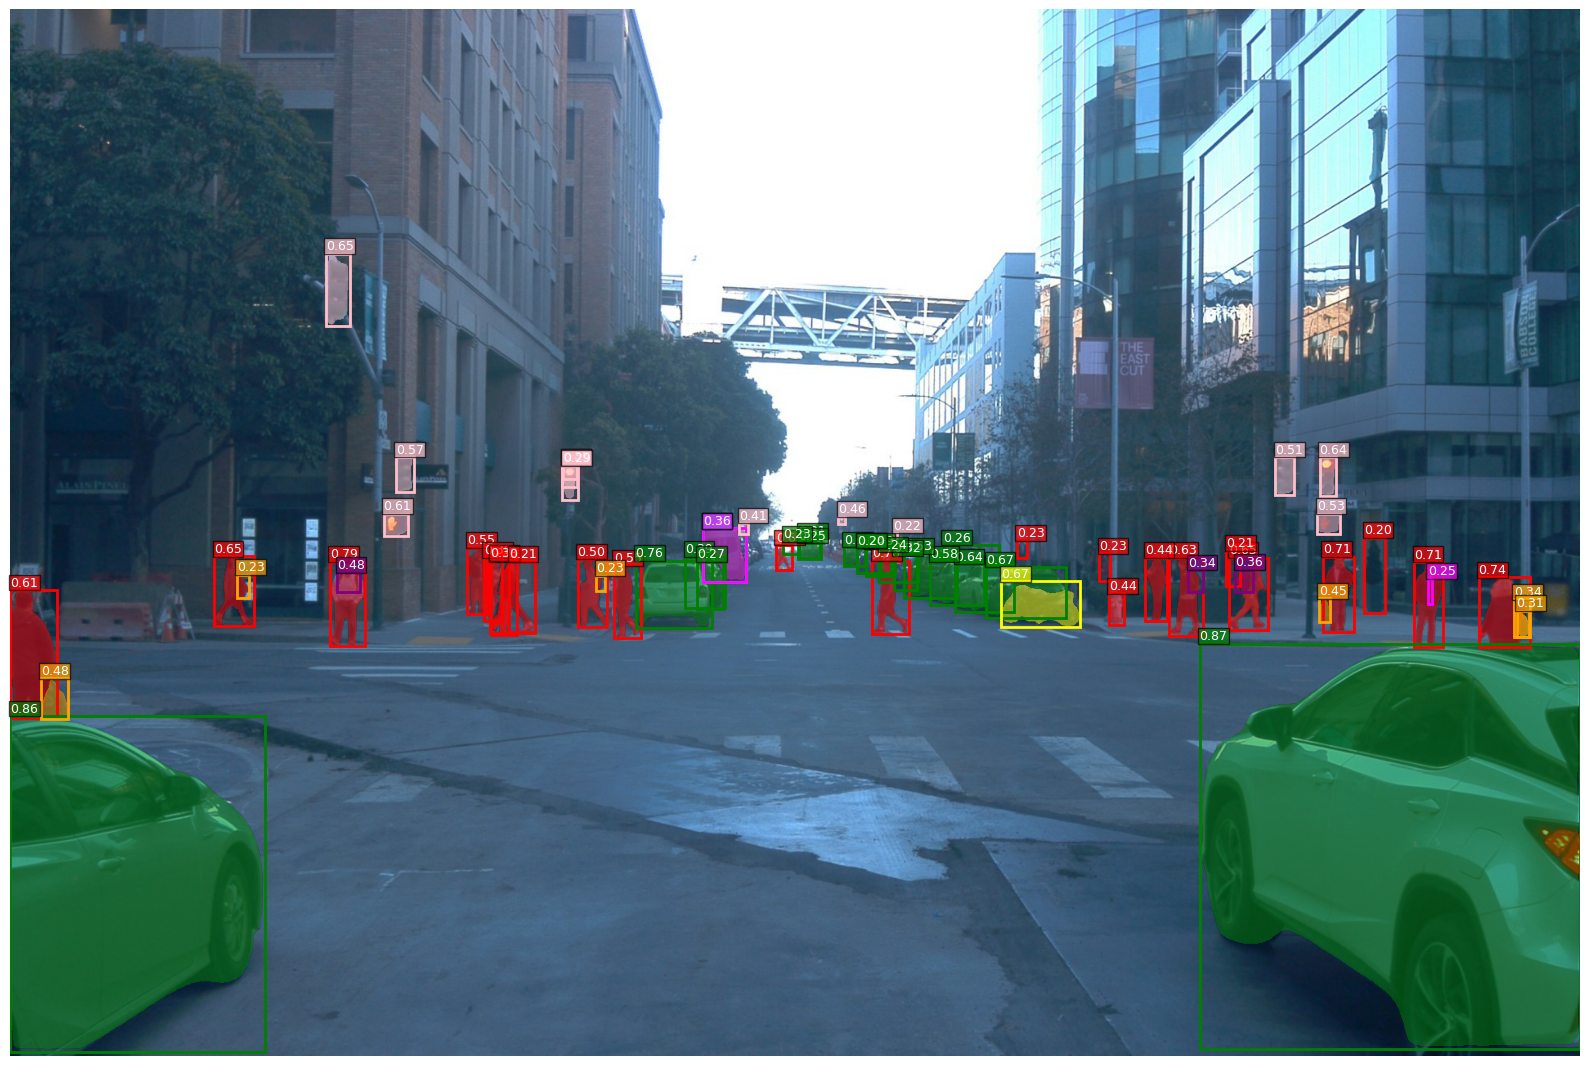

In [17]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def visualize_predictions(frame_preds, reader, preprocess_mask=None):
    # Define a list of distinct colors for different classes
    colors = [
        'red', 'blue', 'green', 'yellow', 'purple', 'cyan', 'orange', 'magenta',
        'lime', 'pink'
    ]

    plt.figure(figsize=(16, 12))
    plt.imshow(reader.get_frame(0)["center_camera_feed"][:, :, ::-1])

    frame_preds = frame_preds.reshape(-1)
    box_preds = frame_preds[0]
    mask_preds = frame_preds[1]
    mask_preds, mask_confidences = mask_preds

    assert len(box_preds) == len(mask_preds) == len(mask_confidences) == 80, (
        len(box_preds), len(mask_preds), len(mask_confidences))

    for class_id, (class_boxes, class_masks, class_mask_confidences) in tqdm(
            enumerate(zip(box_preds, mask_preds, mask_confidences))):
        # Get color for this class (cycle through colors if more classes than
        # colors)
        color = colors[class_id % len(colors)]

        for box in class_boxes:
            x1, y1, x2, y2, score = box
            if score > 0.2:
                # Add bounding box with class-specific color
                plt.gca().add_patch(
                    plt.Rectangle((x1, y1),
                                x2 - x1,
                                y2 - y1,
                                fill=False,
                                edgecolor=color,
                                linewidth=2))

                # Add score label above the box
                plt.text(x1,
                        y1 - 5,
                        f"{score:.2f}",
                        color='white',
                        fontsize=9,
                        bbox=dict(facecolor=color, alpha=0.7, pad=1))

        # For the mask visualization part:
        for mask, confidence in zip(class_masks, class_mask_confidences):
            if preprocess_mask is not None:
                mask = preprocess_mask(mask)
            if confidence > 0.2:
                # Create a colored mask using the same color as the class
                colored_mask = np.zeros((*mask.shape, 4))  # RGBA

                # Convert color name to RGB values
                if isinstance(color, str):
                    rgb = plt.cm.colors.to_rgb(color)
                else:
                    rgb = color

                # Set the mask pixels with alpha
                colored_mask[mask] = (*rgb, 0.5)  # RGB + alpha=0.5

                # Plot the colored mask
                plt.imshow(colored_mask)

    plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_predictions(preds[0], reader)

## Reducing predictions storage size

In [21]:
from pathlib import Path

size_bytes = Path(raw_prediction_path).stat().st_size
size_gb = size_bytes / (1024 * 1024 * 1024)  # Convert to GB
print(f"Storage size of raw predictions with just 10 frames: {size_gb:.2f} GB")

Storage size of raw predictions with just 10 frames: 22.89 GB


### Strategy to reduce storage size:
1. Remove bounding boxes
2. Use RLE encoding for masks (use binary encoding)
3. Remove box predictions (can be reconstructed from masks)
4. Remove low confidence masks (<0.2)
5. gzip save the predictions (might increase load time, need to test)

In [22]:
def optimize_rle_encode_mask(mask, compressed=True):
    """
    Compress a boolean segmentation mask using RLE with optimization.
    
    Args:
        mask: 2D boolean numpy array where True indicates the object
        compressed: Whether to use additional compression on the RLE counts
    
    Returns:
        Compressed representation of the mask
    """
    # Run-length encoding (COCO format)
    mask_uint8 = np.asfortranarray(mask.astype(np.uint8))
    from pycocotools import mask as mask_util
    rle = mask_util.encode(mask_uint8)

    # Convert to more compact format
    if compressed:
        # Store as bytes directly instead of ASCII string
        return {
            "counts":
                rle["counts"] if isinstance(rle["counts"], bytes) else
                rle["counts"].encode('ascii'),
            "size":
                rle["size"]
        }
    else:
        return {
            "counts":
                rle["counts"].decode('ascii') if isinstance(
                    rle["counts"], bytes) else rle["counts"],
            "size":
                rle["size"]
        }


def optimize_rle_decode_mask(rle):
    """
    Decompress a mask from its compressed representation.
    
    Args:
        rle: The compressed mask data
    
    Returns:
        Decompressed boolean mask
    """
    from pycocotools import mask as mask_util

    # Handle both string and bytes formats
    counts = rle["counts"]
    if isinstance(counts, bytes):
        counts = counts
    else:
        counts = counts.encode('ascii') if isinstance(counts, str) else counts

    rle_data = {"counts": counts, "size": rle["size"]}
    mask = mask_util.decode(rle_data)
    return mask.astype(bool)

from copy import deepcopy


def get_mask_preds(frame_preds):
    """
    Remove bounding boxes from the prediction data structure to save space.
    Bounding boxes can be reconstructed from segmentation masks later if
    needed.
    
    Args:
        preds: Original predictions with bounding boxes
        
    Returns:
        Modified predictions with bounding boxes removed
    """
    return frame_preds.reshape(-1)[1]


def filter_mask_preds_by_confidence(frame_mask_preds, conf_threshold=0.2):
    """
    Filter masks by confidence threshold.
    
    Args:
        preds: Prediction data to filter
        conf_threshold: Only keep predictions with confidence above this
        threshold
        
    Returns:
        Filtered predictions and statistics about filtering
    """
    # Create a copy to avoid modifying the original
    frame_mask_preds = deepcopy(frame_mask_preds)

    # Convert from tuple to list
    frame_mask_preds = list(frame_mask_preds)

    filtered_masks = []
    filtered_confs = []

    for class_idx, (class_masks, class_confs) in enumerate(
            zip(frame_mask_preds[0], frame_mask_preds[1])):
        # Filter masks by confidence
        keep_indices = [
            i for i, conf in enumerate(class_confs)
            if conf > conf_threshold
        ]

        # Only keep masks above threshold
        filtered_class_masks = [class_masks[i] for i in keep_indices]
        filtered_class_confs = [class_confs[i] for i in keep_indices]

        filtered_masks.append(filtered_class_masks)
        filtered_confs.append(filtered_class_confs)

        # Update the frame data
    frame_mask_preds = [filtered_masks, filtered_confs]

    return frame_mask_preds


def optimize_mask_encoding(frame_mask_preds, use_binary=True):
    """
    Optimize mask encoding by converting RLE to binary format.
    
    Args:
        preds: Prediction data with masks
        use_binary: Whether to use binary encoding for RLE counts
        
    Returns:
        Predictions with optimized mask encoding
    """
    # Make a copy of the frame predictions
    frame_mask_preds_copy = deepcopy(frame_mask_preds)

    # Optimize mask encoding
    optimized_masks = []

    for class_masks in frame_mask_preds_copy[0]:
        optimized_class_masks = [
            optimize_rle_encode_mask(mask, compressed=use_binary)
            for mask in class_masks
        ]
        optimized_masks.append(optimized_class_masks)

    # Update the frame data
    frame_mask_preds_copy[0] = optimized_masks

    return frame_mask_preds_copy

def clean_preds(frame_preds):
    mask_preds = get_mask_preds(frame_preds)
    mask_preds = filter_mask_preds_by_confidence(mask_preds)
    mask_preds = optimize_mask_encoding(mask_preds)
    return mask_preds

### Benchmark the compression levels of gzip
Gzip has multiple compression levels trading off load speed and compression ratio

100%|██████████| 10/10 [00:23<00:00,  2.33s/it]


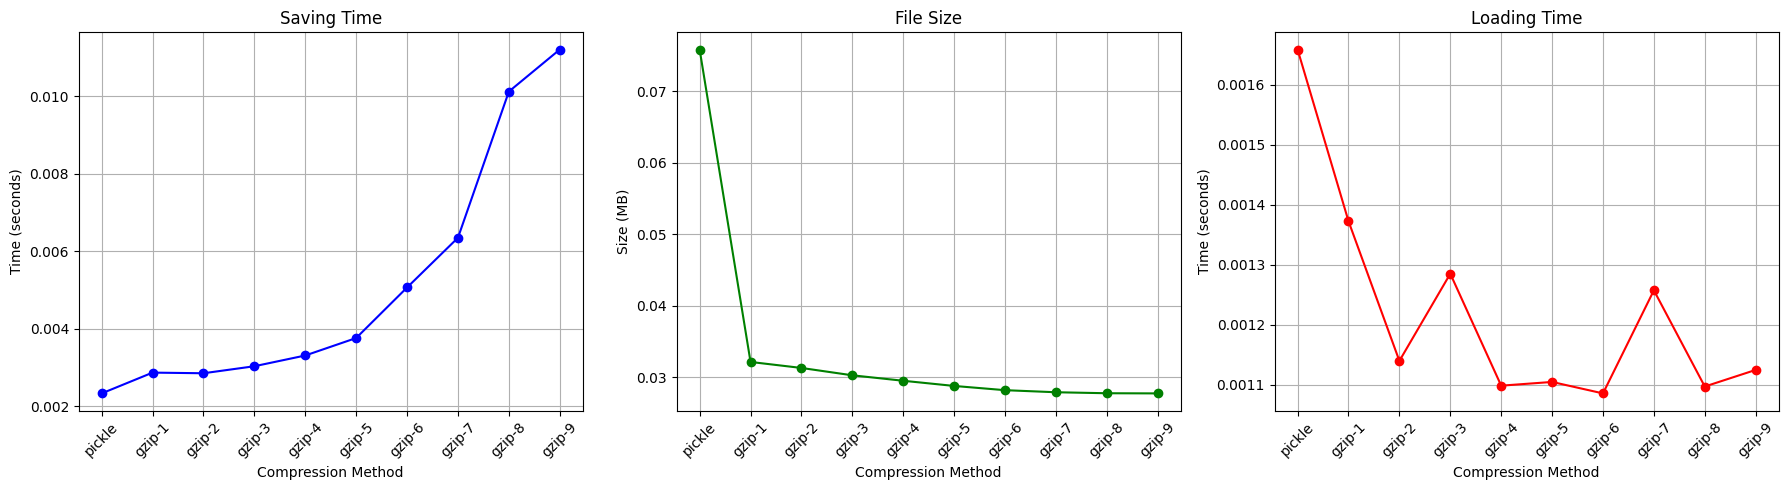

Compression Benchmark Results:
----------------------------------------------------------------------
Method     | Save Time (s)   | File Size (MB)  | Load Time (s)  
----------------------------------------------------------------------
pickle     | 0.002           | 0.076           | 0.002          
gzip-1     | 0.003           | 0.032           | 0.001          
gzip-2     | 0.003           | 0.031           | 0.001          
gzip-3     | 0.003           | 0.030           | 0.001          
gzip-4     | 0.003           | 0.030           | 0.001          
gzip-5     | 0.004           | 0.029           | 0.001          
gzip-6     | 0.005           | 0.028           | 0.001          
gzip-7     | 0.006           | 0.028           | 0.001          
gzip-8     | 0.010           | 0.028           | 0.001          
gzip-9     | 0.011           | 0.028           | 0.001          


In [23]:
def benchmark_compression_levels(data, base_filename="compression_benchmark"):
    """
    Benchmark different compression levels for pickle and gzip.
    
    Args:
        data: The data to compress
        base_filename: Base name for the output files
    
    Returns:
        Dictionary with benchmark results
    """
    import pickle
    import gzip
    import time
    import os
    import matplotlib.pyplot as plt

    results = {
        'method': ['pickle'] + [f'gzip-{i}' for i in range(1, 10)],
        'save_time': [],
        'file_size': [],
        'load_time': []
    }

    # Regular pickle (no compression)
    filename = f"{base_filename}.pkl"
    start_time = time.time()
    with open(filename, 'wb') as f:
        pickle.dump(data, f)
    save_time = time.time() - start_time

    file_size = os.path.getsize(filename) / (1024 * 1024)  # Size in MB

    start_time = time.time()
    with open(filename, 'rb') as f:
        _ = pickle.load(f)
    load_time = time.time() - start_time

    results['save_time'].append(save_time)
    results['file_size'].append(file_size)
    results['load_time'].append(load_time)

    # Gzip with different compression levels
    for level in range(1, 10):
        filename = f"{base_filename}_level{level}.pkl.gz"

        start_time = time.time()
        with gzip.open(filename, 'wb', compresslevel=level) as f:
            pickle.dump(data, f)
        save_time = time.time() - start_time

        file_size = os.path.getsize(filename) / (1024 * 1024)  # Size in MB

        start_time = time.time()
        with gzip.open(filename, 'rb') as f:
            _ = pickle.load(f)
        load_time = time.time() - start_time

        results['save_time'].append(save_time)
        results['file_size'].append(file_size)
        results['load_time'].append(load_time)

    # Plot the results
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Saving time plot
    ax1.plot(results['method'], results['save_time'], 'o-', color='blue')
    ax1.set_title('Saving Time')
    ax1.set_ylabel('Time (seconds)')
    ax1.set_xlabel('Compression Method')
    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45)

    # File size plot
    ax2.plot(results['method'], results['file_size'], 'o-', color='green')
    ax2.set_title('File Size')
    ax2.set_ylabel('Size (MB)')
    ax2.set_xlabel('Compression Method')
    ax2.grid(True)
    ax2.tick_params(axis='x', rotation=45)

    # Loading time plot
    ax3.plot(results['method'], results['load_time'], 'o-', color='red')
    ax3.set_title('Loading Time')
    ax3.set_ylabel('Time (seconds)')
    ax3.set_xlabel('Compression Method')
    ax3.grid(True)
    ax3.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{base_filename}_benchmark.png")
    plt.show()

    # Print the results in a table
    print("Compression Benchmark Results:")
    print("-" * 70)
    print(
        f"{'Method':<10} | {'Save Time (s)':<15} | {'File Size (MB)':<15} | {'Load Time (s)':<15}"
    )
    print("-" * 70)
    for i, method in enumerate(results['method']):
        print(
            f"{method:<10} | {results['save_time'][i]:<15.3f} | {results['file_size'][i]:<15.3f} | {results['load_time'][i]:<15.3f}"
        )

    return results

from more_itertools import flatten

# Simulating saving 200 frames of predictions
cleaned_preds = [clean_preds(p) for p in tqdm(preds)]
simulated_full_preds = list(flatten([cleaned_preds] * 20))

# Example usage:
# Run the benchmark on a subset of your data
benchmark_results = benchmark_compression_levels(simulated_full_preds,
                                                 "compression_test")

### Reduced the storage size of 10 frames from 23GB to 30KB / 20 = 1.5KB

In [ ]:
def save_with_gzip(data, output_file, compression_level=4):
    """
    Save data with gzip compression.
    
    default compression level of 4 was found to be a good compromise between
    compression speed and compression ratio.
    
    Args:
        data: Data to save
        output_file: Path to save the compressed file
        compression_level: gzip compression level (1-9)
        
    Returns:
        File size in MB
    """
    import pickle
    import gzip
    import os
    import time

    print(f"Saving with gzip compression level {compression_level}...")
    start_time = time.time()

    with gzip.open(output_file, 'wb', compresslevel=compression_level) as f:
        pickle.dump(data, f)

    elapsed_time = time.time() - start_time
    file_size_mb = os.path.getsize(output_file) / (1024 * 1024)

    print(f"Saved to {output_file}")
    print(f"File size: {file_size_mb:.2f} MB")
    print(f"Saving time: {elapsed_time:.2f} seconds")

    return file_size_mb


def load_from_gzip(input_file):
    """
    Load data from a gzipped pickle file.
    
    Args:
        input_file: Path to the compressed file
        
    Returns:
        Loaded data
    """
    import pickle
    import gzip
    import time

    print(f"Loading from {input_file}...")
    start_time = time.time()

    with gzip.open(input_file, 'rb') as f:
        data = pickle.load(f)

    elapsed_time = time.time() - start_time

    print(f"Loaded {len(data)} items")
    print(f"Loading time: {elapsed_time:.2f} seconds")

    return data

## Ensure that the cleaned predictions are visualized the same as the raw predictions


80it [00:03, 22.21it/s]


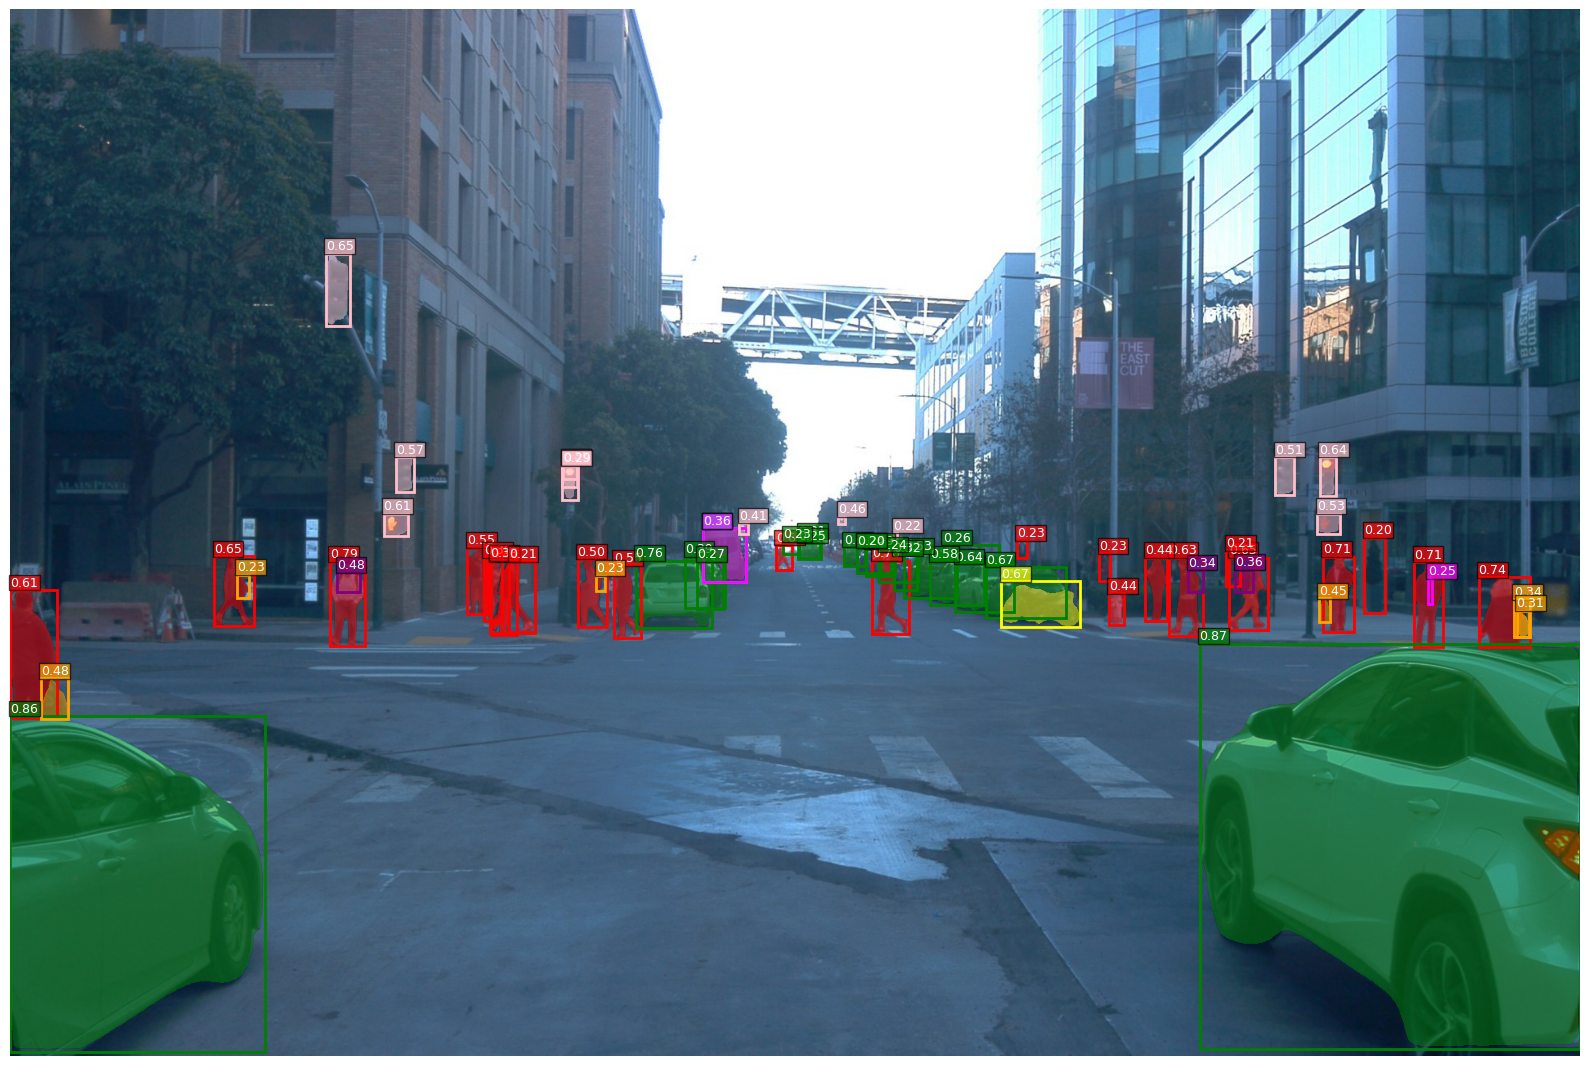

In [24]:
cleaned_mask_preds = clean_preds(preds[0])
original_frame_preds = deepcopy(preds[0])
original_frame_preds.reshape(-1)[1] = cleaned_mask_preds

visualize_predictions(original_frame_preds,
                      reader,
                      preprocess_mask=optimize_rle_decode_mask)